### Handle data

#### Import library and read data

In [32]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from lazypredict.Supervised import LazyClassifier
from sklearn.pipeline import Pipeline

In [33]:
data_df = pd.read_csv('../data/train.csv', index_col='PassengerId')

In [34]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [35]:
# Fill the data with sum miss value > 0
missing_data = data_df.isnull().sum()
print(missing_data[missing_data > 0])

Age         177
Cabin       687
Embarked      2
dtype: int64


In [36]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class TitanicTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        # Khởi tạo các biến để lưu kết quả "học" từ tập Train
        self.mode_embarked_ = None
        self.group_medians_ = None
        self.global_median_age_ = None
        self.rare_prefixes_ = None

    def fit(self, X, y=None):
        X = X.copy()
        
        # 1. Học Mode của Embarked
        self.mode_embarked_ = X['Embarked'].mode()[0]
        
        # 2. Học Median Age theo Sex và Pclass
        self.group_medians_ = X.groupby(["Sex", "Pclass"])["Age"].median()
        self.global_median_age_ = X['Age'].median()
        
        # 3. Học các TicketPrefix hiếm (< 10 lần)
        ticket_clean = X["Ticket"].str.replace(r"[0-9./]", "", regex=True).str.strip()
        ticket_clean = ticket_clean.replace("", "NONE")
        counts = ticket_clean.value_counts()
        self.rare_prefixes_ = counts[counts < 10].index.tolist()
        
        return self

    def transform(self, X):
        X = X.copy()
        
        # --- Xử lý Embarked ---
        X['Embarked'] = X['Embarked'].fillna(self.mode_embarked_)
        
        # --- Xử lý Age ---
        # Điền theo nhóm Sex/Pclass đã học từ tập Train
        X['Age'] = X.apply(
            lambda row: self.group_medians_[row['Sex'], row['Pclass']] 
            if pd.isna(row['Age']) else row['Age'], axis=1
        )
        # Nếu vẫn còn thiếu (do nhóm đó không có trong train), điền bằng median tổng
        X['Age'] = X['Age'].fillna(self.global_median_age_)
        
        # --- Xử lý Sex ---
        X["Sex"] = X["Sex"].map({"male": 0, "female": 1})
        
        # --- Xử lý Cabin (Deck) ---
        X['Deck'] = X['Cabin'].apply(lambda x: 'U' if pd.isna(x) else str(x).split()[0][0])
        
        # --- Xử lý Name & Title ---
        X["Title"] = X["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
        title_mapping = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
        rare_titles = ['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
        X['Title'] = X['Title'].replace(title_mapping)
        X['Title'] = X['Title'].replace(rare_titles, 'Rare')
        
        # --- Xử lý TicketPrefix ---
        X["TicketPrefix"] = X["Ticket"].str.replace(r"[0-9./]", "", regex=True).str.strip()
        X["TicketPrefix"] = X["TicketPrefix"].replace("", "NONE")
        X['TicketPrefix'] = X['TicketPrefix'].apply(lambda x: 'RAZE' if x in self.rare_prefixes_ else x)
        
        # --- Family Features ---
        X['FamilySize'] = X['SibSp'] + X['Parch'] + 1
        X['IsAlone'] = (X['FamilySize'] == 1).astype(int)
        
        # --- Surname & Group Features ---
        X["Surname"] = X["Name"].str.split(",").str[0]
        X["SurnameCount"] = X.groupby("Surname")["Surname"].transform("count")
        X["TicketGroupSize"] = X.groupby("Ticket")["Ticket"].transform("count")
        
        # --- Drop columns ---
        cols_to_drop = ['Ticket', 'Cabin', 'Name', 'Surname']
        X.drop(columns=[c for c in cols_to_drop if c in X.columns], inplace=True)
        
        return X

In [37]:
num_feature = ['Age', 'Fare','SurnameCount', 'FamilySize', 'TicketGroupSize']
cat_feature = [ 'Embarked', 'Title', 'TicketPrefix', 'Deck']

In [38]:
# Làm sạch, phân loại lỹ ở đây 

In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_feature),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_feature)
    ], 
    remainder='passthrough' # Tự động giữ lại 'Sex', 'IsAlone', 'Pclass'
)

In [54]:
from sklearn.svm import SVC


model_pipeline = Pipeline(steps=[
    ('feature_engineering', TitanicTransformer()), # Bước của bạn
    ('preprocessing', preprocessor),                # Bước làm sạch/mã hóa
    ('classifier', SVC(gamma = 'auto'))
])

In [41]:
# Lấy ra target cần dự đoán
target = 'Survived'

In [42]:
x = data_df.drop(columns=[target], axis = 1)
y = data_df[target]

In [43]:
# Stratify ( phân chia để k bị lệch data giữa train và test)
X_train, X_test, Y_train, Y_test = train_test_split(x,y, train_size = 0.8, random_state=1)

In [55]:
model_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of th

In [56]:
from sklearn.metrics import classification_report

# 1. Lấy dự đoán từ tập test
y_pred = model_pipeline.predict(X_test)

# 2. In báo cáo chi tiết
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       106
           1       0.81      0.71      0.76        73

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



### Quy trình đúng nên là:

- Phân loại (Numeric vs Categorical).

- Phân loại con (Nominal vs Ordinal, Discrete vs Continuous).

- Xử lý dữ liệu thiếu (Imputation).

- Encoding & Scaling.

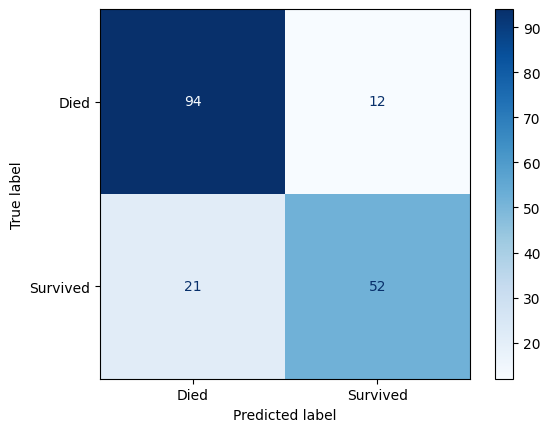

In [57]:
# Ma trận nhầm lẫn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])
disp.plot(cmap='Blues')
plt.show()

In [ ]:
#3. Kiểm tra "Học vẹt" (Cross-Validation)
#Nếu bạn thấy Accuracy trên tập Train là 99% nhưng tập Test chỉ 75%, mô hình của bạn đang bị Overfitting (Học vẹt). Hãy dùng Cross-Validation để xem độ ổn định của nó.
from sklearn.model_selection import cross_val_score

# Chia dữ liệu thành 5 phần và chấm điểm 5 lần
scores = cross_val_score(model_pipeline, x, y, cv=5)

print(f"Độ chính xác trung bình: {scores.mean():.2%}")
print(f"Độ lệch (Sự ổn định): {scores.std():.2%}")

Độ chính xác trung bình: 81.82%
Độ lệch (Sự ổn định): 3.16%


In [60]:
import joblib

# Giả sử 'model_pipeline' là Pipeline chứa SVC của bạn đã được .fit()
# Lưu mô hình vào file .pkl
joblib.dump(model_pipeline, '../models/titanic_svc_model.pkl')

print("Đã lưu model SVC thành công!")

Đã lưu model SVC thành công!


In [ ]:
# X_train_transformed = model_pipeline.fit_transform(X_train, Y_train)
# X_test_transformed = model_pipeline.transform(X_test)

In [ ]:
# # Khởi tạo
# lazy_clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# # Chú ý thứ tự biến và cách lấy kết quả
# models, predictions = lazy_clf.fit(X_train_transformed, X_test_transformed, Y_train, Y_test)

# # QUAN TRỌNG: In 'models' để thấy bảng xếp hạng
# display(models)

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
SVC,0.821229,0.806410,0.831158,0.819298,0.820819,0.821229,0.039261
AdaBoostClassifier,0.810056,0.803373,0.828638,0.810056,0.810056,0.810056,0.113556
NuSVC,0.810056,0.796976,0.821465,0.808600,0.809037,0.810056,0.048145
LinearSVC,0.804469,0.792259,0.825213,0.803255,0.803341,0.804469,0.018952
RidgeClassifierCV,0.804469,0.792259,0.826376,0.803255,0.803341,0.804469,0.028322
RidgeClassifier,0.804469,0.792259,0.825342,0.803255,0.803341,0.804469,0.013394
LinearDiscriminantAnalysis,0.804469,0.792259,0.825730,0.803255,0.803341,0.804469,0.023021
CalibratedClassifierCV,0.798883,0.785410,0.827798,0.797341,0.797663,0.798883,0.060255
LogisticRegression,0.793296,0.782825,0.827927,0.792570,0.792301,0.793296,0.029677
